# Pima Indians Diabetes XGBoost 분류

## 개요
- XGBoost Classifier로 당뇨병 예측
- 최적화된 Gradient Boosting
- 병렬 처리 및 정규화 기능

## 주요 단계
1. 데이터 로드 및 분리
2. XGBoost 설정
3. GridSearchCV 최적화
4. 성능 평가 및 피처 중요도

## 라이브러리 임포트

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import accuracy_score, classification_report

## 1. 데이터 로드

**Pima Indians Diabetes 데이터셋**
- 768개 샘플, 8개 피처
- 당뇨병 발병 여부 이진 분류

In [6]:
pima.target

,class
0,tested_positive
1,tested_negative
2,tested_positive
3,tested_negative
4,tested_positive
...,...
763,tested_negative
764,tested_negative
765,tested_negative
766,tested_positive


In [7]:
print("Loading Pima Indians Diabetes Dataset...")
pima = fetch_openml(name='diabetes', version=1, as_frame=True)
X = pima.data
y = pima.target.map({'tested_negative': 0, 'tested_positive': 1}).astype(int)

print(f"데이터 크기: {X.shape}")
print(f"피처 목록: {list(X.columns)}")
print(f"\n클래스 분포:\n{y.value_counts()}")

Loading Pima Indians Diabetes Dataset...
데이터 크기: (768, 8)
피처 목록: ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']

클래스 분포:
class
0    500
1    268
Name: count, dtype: int64


**데이터 샘플 확인**

In [8]:
# 데이터 샘플
print("\n데이터 샘플:")
print(X.head())

print("\n기술 통계:")
print(X.describe())


데이터 샘플:
   preg  plas  pres  skin  insu  mass   pedi  age
0     6   148    72    35     0  33.6  0.627   50
1     1    85    66    29     0  26.6  0.351   31
2     8   183    64     0     0  23.3  0.672   32
3     1    89    66    23    94  28.1  0.167   21
4     0   137    40    35   168  43.1  2.288   33

기술 통계:
             preg        plas        pres        skin        insu        mass  \
count  768.000000  768.000000  768.000000  768.000000  768.000000  768.000000   
mean     3.845052  120.894531   69.105469   20.536458   79.799479   31.992578   
std      3.369578   31.972618   19.355807   15.952218  115.244002    7.884160   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      1.000000   99.000000   62.000000    0.000000    0.000000   27.300000   
50%      3.000000  117.000000   72.000000   23.000000   30.500000   32.000000   
75%      6.000000  140.250000   80.000000   32.000000  127.250000   36.600000   
max     17.000000  199.000000  122.

**학습/테스트 데이터 분리**

In [9]:
# 데이터 분리 (stratify로 클래스 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nTrain 클래스 분포:\n{y_train.value_counts()}")

Train: (614, 8), Test: (154, 8)

Train 클래스 분포:
class
0    400
1    214
Name: count, dtype: int64


## 2. XGBoost Classifier

**XGBoost vs Gradient Boosting**
- 병렬 처리: 트리 내 분할 병렬화
- 정규화: L1(alpha), L2(lambda)
- 가지치기: max_depth 후 가지치기
- 결측치: 자동 처리 (방향 학습)
- 속도: 훨씬 빠름

**핵심 개선사항**
- Cache-aware access: 메모리 효율
- Block structure: 병렬 처리
- Sparsity-aware: 희소 데이터
- Weighted quantile: 샘플 가중치

**하이퍼파라미터**
- n_estimators: 트리 개수
- learning_rate: 학습률 (eta)
- max_depth: 트리 깊이
- subsample: 행 샘플링
- colsample_bytree: 열 샘플링
- gamma: 최소 손실 감소 (가지치기)
- reg_alpha: L1 정규화
- reg_lambda: L2 정규화

**모델 설정**

In [10]:
# XGBoost Classifier
xgb_clf = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

print("XGBoost Classifier 생성")
print(f"기본 설정: n_estimators=100, learning_rate=0.3, max_depth=6")

XGBoost Classifier 생성
기본 설정: n_estimators=100, learning_rate=0.3, max_depth=6


## 3. GridSearchCV 하이퍼파라미터 탐색

**파라미터 그리드**
- n_estimators: [100, 200]
- learning_rate: [0.01, 0.05, 0.1]
- max_depth: [3, 5, 7]
- subsample: [0.8, 1.0]
- colsample_bytree: [0.8, 1.0]

**파라미터 의미**
- subsample: 과적합 방지 (Stochastic GB)
- colsample_bytree: Random Forest 아이디어

In [11]:
# 하이퍼파라미터 그리드
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

print("파라미터 그리드:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

total_combinations = 1
for values in param_grid.values():
    total_combinations *= len(values)
print(f"\n총 조합 수: {total_combinations}개")

파라미터 그리드:
  n_estimators: [100, 200]
  learning_rate: [0.01, 0.05, 0.1]
  max_depth: [3, 5, 7]
  subsample: [0.8, 1.0]
  colsample_bytree: [0.8, 1.0]

총 조합 수: 72개


In [12]:
# GridSearchCV
print("\nTuning XGBoost Classifier...")
print("(교차검증 수행 중...)\n")

grid_clf = GridSearchCV(
    xgb_clf,
    param_grid,
    cv=StratifiedKFold(5),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_clf.fit(X_train, y_train)
print("\nGridSearchCV 완료!")


Tuning XGBoost Classifier...
(교차검증 수행 중...)

Fitting 5 folds for each of 72 candidates, totalling 360 fits

GridSearchCV 완료!


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [03:25:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## 4. 최적화 결과 분석

**최적 모델 정보**

In [13]:
# 최적 모델 추출
best_clf = grid_clf.best_estimator_

print("[최적화 결과]")
print(f"Best Accuracy (Train CV): {grid_clf.best_score_:.4f}")
print(f"\nBest Parameters:")
for param, value in grid_clf.best_params_.items():
    print(f"  {param}: {value}")

[최적화 결과]
Best Accuracy (Train CV): 0.7720

Best Parameters:
  colsample_bytree: 0.8
  learning_rate: 0.01
  max_depth: 3
  n_estimators: 200
  subsample: 0.8


**GridSearchCV 상위 결과**

In [14]:
# 상위 5개 결과
cv_results = pd.DataFrame(grid_clf.cv_results_)
top_results = cv_results.nlargest(5, 'mean_test_score')[[
    'param_n_estimators',
    'param_learning_rate',
    'param_max_depth',
    'param_subsample',
    'param_colsample_bytree',
    'mean_test_score',
    'std_test_score'
]]

print("\n상위 5개 파라미터 조합:")
print(top_results.to_string(index=False))


상위 5개 파라미터 조합:
 param_n_estimators  param_learning_rate  param_max_depth  param_subsample  param_colsample_bytree  mean_test_score  std_test_score
                200                 0.01                3              0.8                     0.8         0.772038        0.024243
                200                 0.01                3              0.8                     1.0         0.765547        0.032243
                200                 0.01                7              0.8                     1.0         0.762282        0.041580
                200                 0.01                5              0.8                     0.8         0.760629        0.033281
                200                 0.01                3              1.0                     1.0         0.759043        0.030580


## 5. 테스트 데이터 평가

**예측 및 성능 평가**

In [15]:
# 테스트 데이터 예측
y_pred = best_clf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.7662

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       100
           1       0.71      0.56      0.62        54

    accuracy                           0.77       154
   macro avg       0.75      0.72      0.73       154
weighted avg       0.76      0.77      0.76       154



**Confusion Matrix**

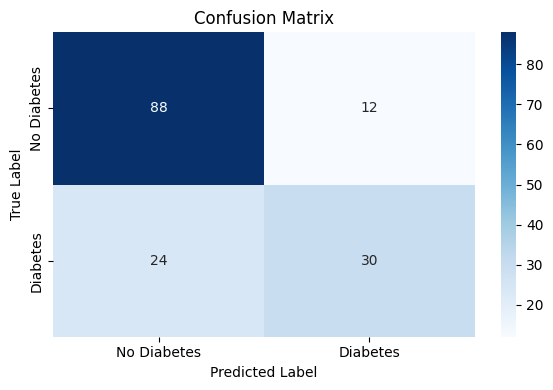

In [21]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 6. 피처 중요도 분석

**XGBoost 피처 중요도 타입**
- weight: 피처가 사용된 횟수
- gain: 평균 손실 감소량 (기본)
- cover: 평균 샘플 수

**gain 추천 이유**
- 실제 예측 개선 정도 반영
- 가장 해석 가능

**XGBoost 내장 시각화**

<Figure size 1000x800 with 0 Axes>

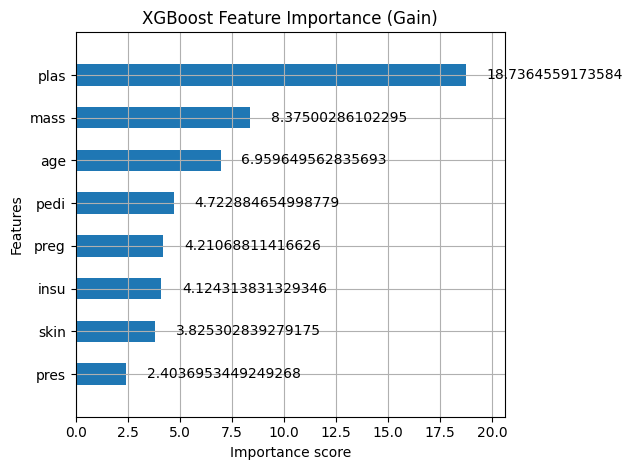

In [17]:
# XGBoost plot_importance
plt.figure(figsize=(10, 8))
plot_importance(best_clf, max_num_features=10,
                importance_type='gain', height=0.5)
plt.title("XGBoost Feature Importance (Gain)")
plt.tight_layout()
plt.show()

**수동 피처 중요도 추출 및 시각화**


피처 중요도 순위:
Feature  Importance
   plas    0.351146
   mass    0.156959
    age    0.130433
   pedi    0.088513
   preg    0.078914
   insu    0.077295
   skin    0.071691
   pres    0.045048


/tmp/ipython-input-3096514809.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')


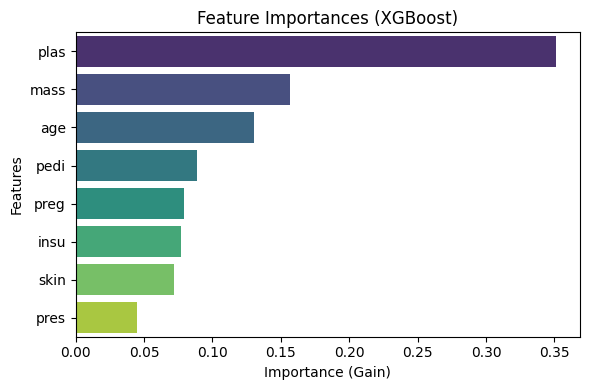

In [22]:
# 피처 중요도 추출
importances = best_clf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# 중요도 정렬
importance_df = pd.DataFrame({
    'Feature': feature_names[indices],
    'Importance': importances[indices]
})

print("\n피처 중요도 순위:")
print(importance_df.to_string(index=False))

# 시각화
plt.figure(figsize=(6, 4))
sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')
plt.title("Feature Importances (XGBoost)")
plt.xlabel("Importance (Gain)")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## 8. Early Stopping

**Early Stopping 장점**
- 과적합 방지
- 학습 시간 단축
- 최적 트리 개수 자동 선택

In [23]:
# Early Stopping with eval_set
xgb_early = XGBClassifier(
    **grid_clf.best_params_,
    early_stopping_rounds=10,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Validation set 분리
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# 학습 (eval_set 제공)
xgb_early.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f"\nEarly Stopping:")
print(f"최적 트리 개수: {xgb_early.best_iteration + 1}")
print(f"설정 트리 개수: {grid_clf.best_params_['n_estimators']}")
print(f"Test Accuracy: {xgb_early.score(X_test, y_test):.4f}")


Early Stopping:
최적 트리 개수: 200
설정 트리 개수: 200
Test Accuracy: 0.7208


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [03:27:28] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
